# 10 - 单张图像 3D 人脸重建（严格版）


## 0. 环境准备
在 `D:\InternProject` 项目终端执行：

```powershell
python -m pip install -r .\face-vision-lab\face_effects\requirements_3d_strict.txt
```

## 1. 任务 8.1：原理

**3DMM** 将三维人脸写成平均脸和统计基的线性组合：`S = S_mean + B_id α_id + B_exp α_exp`。3DDFA_V2 用神经网络从单张图像回归身份、表情、旋转、平移及弱透视投影参数，再用 BFM 解码稠密网格。它适合本实验的单图快速重建。

**NeRF** 学习空间位置与观察方向到体密度和颜色的连续映射，通过体渲染生成新视角。传统 NeRF 通常依赖多视角图像和逐场景优化，所以本实验不选择它做单图交付。

In [1]:
import sys
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'face_effects':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from face_effects.face_3d_strict import (
    dependency_report, prepare_3ddfa, reconstruct_with_3ddfa,
    render_opengl_multiview, save_dense_overlay,
    save_strict_metadata, save_strict_report,
)

repo_dir = PROJECT_ROOT / 'third_party/3DDFA_V2'
output_dir = PROJECT_ROOT / 'work_dirs/face_3d_strict'
output_dir.mkdir(parents=True, exist_ok=True)
dependency_report()

{'python': '3.11.4',
 'torch': '2.1.0+cu118',
 'opencv': '4.10.0',
 'numpy': '1.26.4',
 'onnxruntime': '1.29.0',
 'pyrender': '0.1.45',
 'trimesh': '4.12.2'}

## 2. 输入图像

默认使用 CelebA 正面人脸，也可以换成自己的清晰单人人脸照片。

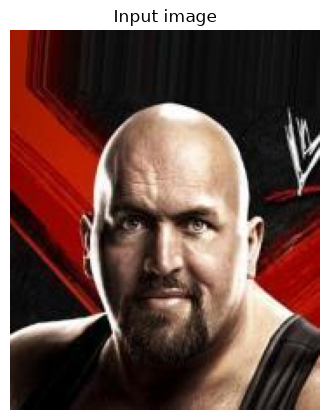

In [12]:
image_path = PROJECT_ROOT / 'data/CelebA/img_align_celeba/001117.jpg'
image = cv2.imread(str(image_path))
if image is None:
    raise FileNotFoundError(image_path)
plt.figure(figsize=(4, 5))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input image')
plt.show()

## 3. 任务 8.2：官方 3DDFA_V2 重建

首次执行会获取固定版本的官方仓库，并将官方 PyTorch 权重转换为 ONNX；这不是训练。Windows 无需编译 Cython/CUDA 扩展。

In [13]:
setup_start = time.perf_counter()
prepare_3ddfa(repo_dir)
setup_seconds = time.perf_counter() - setup_start
print(f'Official 3DDFA_V2 prepared in {setup_seconds:.2f} s')

Official 3DDFA_V2 prepared in 0.05 s


In [14]:
reconstruction_start = time.perf_counter()
mesh = reconstruct_with_3ddfa(image_path, repo_dir, output_dir)
reconstruction_seconds = time.perf_counter() - reconstruction_start
print(f"vertices: {len(mesh['vertices']):,}")
print(f"triangles: {len(mesh['triangles']):,}")
print(f'reconstruction: {reconstruction_seconds:.3f} s')
print('OBJ:', mesh['obj_path'])

Dump tp D:\InternProject\face-vision-lab\work_dirs\face_3d_strict\3ddfa_reconstructed_face.obj
vertices: 38,365
triangles: 76,073
reconstruction: 0.533 s
OBJ: D:\InternProject\face-vision-lab\work_dirs\face_3d_strict\3ddfa_reconstructed_face.obj


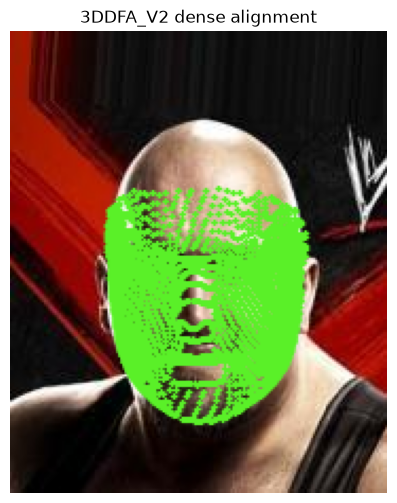

In [15]:
overlay_path = save_dense_overlay(output_dir / '3ddfa_dense_overlay.png', mesh)
overlay = cv2.imread(str(overlay_path))
plt.figure(figsize=(5, 6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('3DDFA_V2 dense alignment')
plt.show()

## 4. 任务 8.3：OpenGL 多角度渲染

将同一个重建网格绕 Y 轴旋转 -35°、0°、35°，由 pyrender 的 OpenGL 离屏渲染器生成三视图。

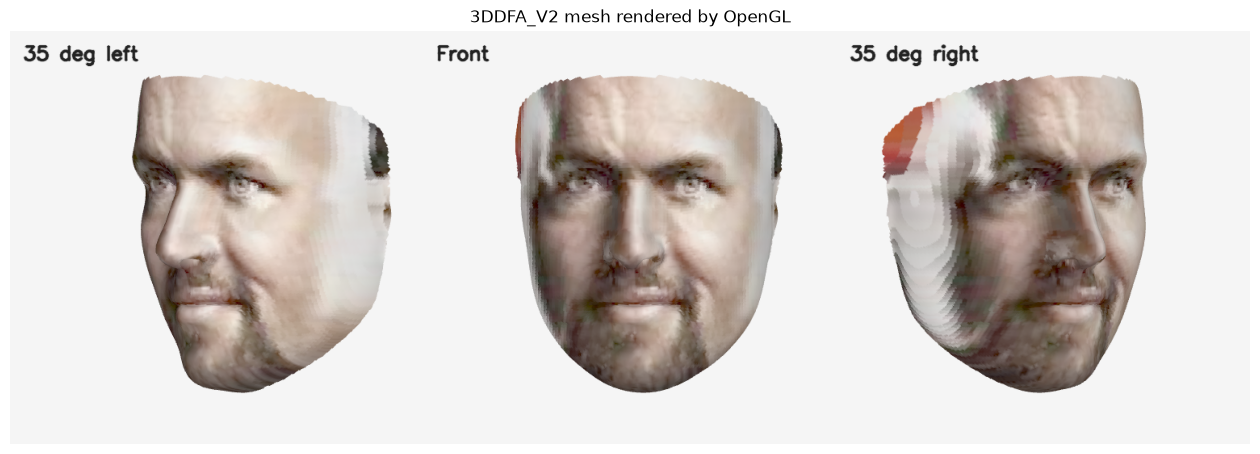

OpenGL rendering: 0.285 s


In [16]:
render_start = time.perf_counter()
views_path = render_opengl_multiview(
    output_dir / '3ddfa_opengl_multiview.png', mesh, angles=(-35, 0, 35)
)
render_seconds = time.perf_counter() - render_start
views = cv2.imread(str(views_path))
plt.figure(figsize=(16, 6))
plt.imshow(cv2.cvtColor(views, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('3DDFA_V2 mesh rendered by OpenGL')
plt.show()
print(f'OpenGL rendering: {render_seconds:.3f} s')

## 5. 实验记录与实验结果

### 5.1 实验环境

| 项目 | 本次实际环境 |
|---|---|
| Python | 3.11.4 |
| PyTorch | 2.1.0+cu118 |
| OpenCV | 4.10.0 |
| NumPy | 1.26.4 |
| ONNX Runtime | 1.29.0 |
| pyrender / trimesh | 0.1.45 / 4.12.2 |

### 5.2 实际结果

| 指标 | 实测结果 |
|---|---:|
| FaceBoxes 检测置信度 | 0.9969 |
| 稠密网格顶点数 | 38,365 |
| 三角面数 | 76,073 |
| 3DDFA_V2 重建耗时 | 0.533 s |
| OpenGL 三视图渲染耗时 | 0.285 s |

模型成功导出为 `3ddfa_reconstructed_face.obj`。稠密点对齐图显示顶点覆盖眼睛、鼻子、嘴部、下颌和额头等主要区域；OpenGL 结果成功生成左 35°、正面和右 35°三个视角，证明输出是可旋转渲染的三维网格，而不是二维图像变换。下面继续保存 JSON 元数据及独立 Markdown 实验报告。

In [17]:
metrics = {
    'initial_setup': round(setup_seconds, 3),
    'reconstruction': round(reconstruction_seconds, 3),
    'rendering': round(render_seconds, 3),
}
metadata = save_strict_metadata(
    output_dir / 'strict_reconstruction_metadata.json', mesh, image_path,
    metrics=metrics, dependencies=dependency_report(),
)
report_path = save_strict_report(output_dir / '严格版实验记录与结果.md', metadata)
print('metadata:', output_dir / 'strict_reconstruction_metadata.json')
print('report:', report_path)
metadata

metadata: d:\InternProject\face-vision-lab\work_dirs\face_3d_strict\strict_reconstruction_metadata.json
report: d:\InternProject\face-vision-lab\work_dirs\face_3d_strict\严格版实验记录与结果.md


{'task': '8.2-8.3 strict',
 'reconstruction': 'official 3DDFA_V2 ONNX (3DMM parameter regression)',
 'official_commit': '1b6c67601abffc1e9f248b291708aef0e43b55ae',
 'rendering': 'pyrender OpenGL offscreen renderer',
 'source_image': 'D:\\InternProject\\face-vision-lab\\data\\CelebA\\img_align_celeba\\001117.jpg',
 'vertex_count': 38365,
 'triangle_count': 76073,
 'face_box_xyxy_score': [49.795021057128906,
  60.719398498535156,
  134.5259552001953,
  192.48744201660156,
  0.9969379901885986],
 'obj_path': 'D:\\InternProject\\face-vision-lab\\work_dirs\\face_3d_strict\\3ddfa_reconstructed_face.obj',
 'metrics_seconds': {'initial_setup': 0.054,
  'reconstruction': 0.533,
  'rendering': 0.285},
 'dependencies': {'python': '3.11.4',
  'torch': '2.1.0+cu118',
  'opencv': '4.10.0',
  'numpy': '1.26.4',
  'onnxruntime': '1.29.0',
  'pyrender': '0.1.45',
  'trimesh': '4.12.2'}}

## 6. 结果分析、结论与验收

### 结果分析

1. **几何重建有效：** 3DDFA_V2 输出 38,365 个顶点和 76,073 个三角面，五官轮廓与输入图像基本对齐，满足稠密单图人脸重建要求。
2. **多视角渲染有效：** 左、正、右视图呈现连续的鼻梁、面颊和下颌深度变化，说明 OpenGL 正确渲染了同一个三维网格。
3. **运行效率较高：** 已完成模型准备后，单张图像重建约 0.533 秒，三视图渲染约 0.285 秒，适合离线实验展示。
4. **方法限制：** 输入只有正面纹理，左右旋转后耳侧和不可见区域存在拉伸与颜色重复；这属于单图重建缺少遮挡面观测的固有限制，不影响本实验对几何重建和多视角渲染流程的验证。

### 实验结论

本实验使用官方 3DDFA_V2 从 CelebA 单张人脸图像回归 3DMM 参数，成功恢复稠密 BFM 人脸网格并导出 OBJ；随后使用 pyrender/OpenGL 完成 -35°、0°、35°三视角可视化。实验结果表明，该流程能够在无需重新训练的情况下完成稳定的单图三维人脸重建，任务 8.1、8.2 和 8.3 均已完成。

### 验收清单

- [x] 8.1：说明 3DMM、3DDFA_V2 与 NeRF 的基本原理及算法选型。
- [x] 8.2：使用官方 3DDFA_V2 完成单张图像三维人脸重建并导出 OBJ。
- [x] 8.3：使用 pyrender/OpenGL 完成左、正、右多角度渲染。
- [x] 交付物：代码、OBJ、稠密点对齐图、OpenGL 多视角图、JSON 元数据和实验报告。